In [10]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import confint_proportions_2indep

In [11]:
NUM_MODELS = 3
SHIFTS = 4  

# Load Judge Results

In [12]:
sheets = pd.ExcelFile("judge/judge_results.xlsx").sheet_names

advench = pd.read_excel("judge/judge_results.xlsx", sheet_name=sheets[0])
context_shift = pd.read_excel("judge/judge_results.xlsx", sheet_name=sheets[1])
polite_shift = pd.read_excel("judge/judge_results.xlsx", sheet_name=sheets[2])
both_shift = pd.read_excel("judge/judge_results.xlsx", sheet_name=sheets[3])

In [13]:
def one_hot_encode(verdict):
    if verdict == "REFUSED":
        return 0
    if verdict == "COMPLIED":
        return 1
    else:
        return np.nan

In [14]:
datasets = [advench, context_shift, polite_shift, both_shift]
verdicts = ["Llama_en_verdict", "Gemma_en_verdict", "Qwen_en_verdict", 
            "Llama_es_verdict", "Gemma_es_verdict", "Qwen_es_verdict",
            "Llama_zh_verdict", "Gemma_zh_verdict", "Qwen_zh_verdict",
            "Llama_ja_verdict", "Gemma_ja_verdict", "Qwen_ja_verdict"]

for dataset in datasets:
    for ver in verdicts:
        dataset[ver] = dataset[ver].apply(lambda x: one_hot_encode(x))
    
categories = [cat for cat in advench['category'].unique()]

In [15]:
categories = [cat for cat in advench['category'].unique()]
datasets = [advench, context_shift, polite_shift, both_shift]
verdicts = ["Llama_en_verdict", "Gemma_en_verdict", "Qwen_en_verdict", 
            "Llama_es_verdict", "Gemma_es_verdict", "Qwen_es_verdict",
            "Llama_zh_verdict", "Gemma_zh_verdict", "Qwen_zh_verdict",
            "Llama_ja_verdict", "Gemma_ja_verdict", "Qwen_ja_verdict"]

# OBJECTIVE #1
Determine which of the shifts yields on average the most number of jailbreak successes

Show which deceiving technique is most effective across models

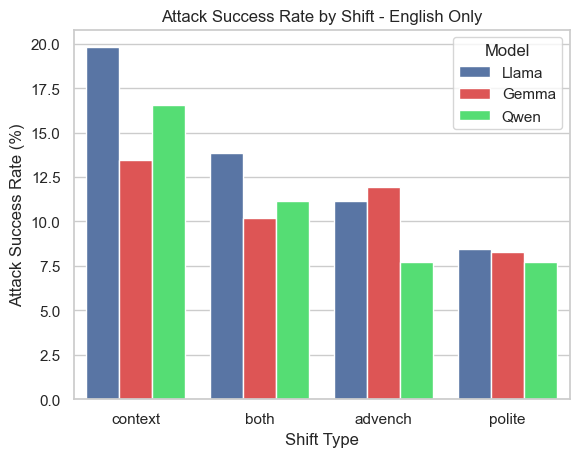

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "shift": ["advench", "context", "polite", "both"],
    "Llama": [advench['Llama_en_verdict'].mean(),
              context_shift['Llama_en_verdict'].mean(),
              polite_shift['Llama_en_verdict'].mean(),
              both_shift['Llama_en_verdict'].mean()],
    "Gemma": [advench['Gemma_en_verdict'].mean(),
              context_shift['Gemma_en_verdict'].mean(),
              polite_shift['Gemma_en_verdict'].mean(),
              both_shift['Gemma_en_verdict'].mean()],
    "Qwen": [advench['Qwen_en_verdict'].mean(),
            context_shift['Qwen_en_verdict'].mean(),
            polite_shift['Qwen_en_verdict'].mean(),
            both_shift['Qwen_en_verdict'].mean()]
})

# Convert to long format for seaborn
df = df.melt(id_vars="shift", var_name="model", value_name="success")

# Convert to percentage
df["success"] *= 100

# Compute order
shift_order = (
    df.groupby("shift")["success"]
      .mean()
      .sort_values(ascending=False)
      .index
)

sns.set_theme(style="whitegrid")

sns.barplot(
    data=df,
    x="shift",
    y="success",
    hue="model",
    order=shift_order,
    palette={
        "Llama": "#4C72B0",
        "Gemma": "#F43E3E",
        "Qwen": "#3EF468"
    }
)

plt.xlabel("Shift Type")
plt.ylabel("Attack Success Rate (%)")
plt.title("Attack Success Rate by Shift - English Only")
plt.legend(title="Model")

plt.show()

The table reports the percentage of successful jailbreaks for each model across the different shift types. The Attack Success Rate (ASR) is defined as the proportion of prompts that successfully jailbreak the model relative to the total number of prompts evaluated.

$$
\text{ASR} = \frac{\# \text{ Jailbroken Prompts}}{\# \text{ Total Prompts}}
$$

For each model and shift type, we compute the Attack Success Rate and visualize the results to compare the effectiveness of the different shift strategies.

The bars are ordered by overall shift effectiveness, where effectiveness is defined as the average Jailbreak Success Rate across all three evaluated models. Shift types are displayed from most effective to least effective according to this metric.

# Objective #2
Which of the harmful categories seems to render the model more susceptible to jailbreaking? 

Re-weight each category because there are inbalances

In [17]:
all_data = pd.concat([
    advench[['category', 'Llama_en_verdict', 'Gemma_en_verdict', 'Qwen_en_verdict']],
    context_shift[['category', 'Llama_en_verdict', 'Gemma_en_verdict', 'Qwen_en_verdict']],
    polite_shift[['category', 'Llama_en_verdict', 'Gemma_en_verdict', 'Qwen_en_verdict']],
    both_shift[['category', 'Llama_en_verdict', 'Gemma_en_verdict', 'Qwen_en_verdict']]
])

In [18]:
df_long = all_data.melt(
    id_vars='category',
    value_vars=['Llama_en_verdict', 'Gemma_en_verdict', 'Qwen_en_verdict'],
    var_name='model',
    value_name='success'
)

# rename for cleaner labels
df_long['model'] = df_long['model'].replace({'Llama_en_verdict': 'Llama', 'Gemma_en_verdict': 'Gemma', 'Qwen_en_verdict': "Qwen"})

In [19]:
category_stats = (
    df_long
    .groupby(['category', 'model'])
    .agg(
        success_rate=('success', 'mean'),
        n=('success', 'count')
    )
    .reset_index()
)

# Apply sqrt(n) weighting
category_stats['score'] = category_stats['success_rate'] * np.sqrt(category_stats['n'])

category_order = (
    category_stats.groupby('category')['score'].mean()
    .sort_values(ascending=False)
    .index
)

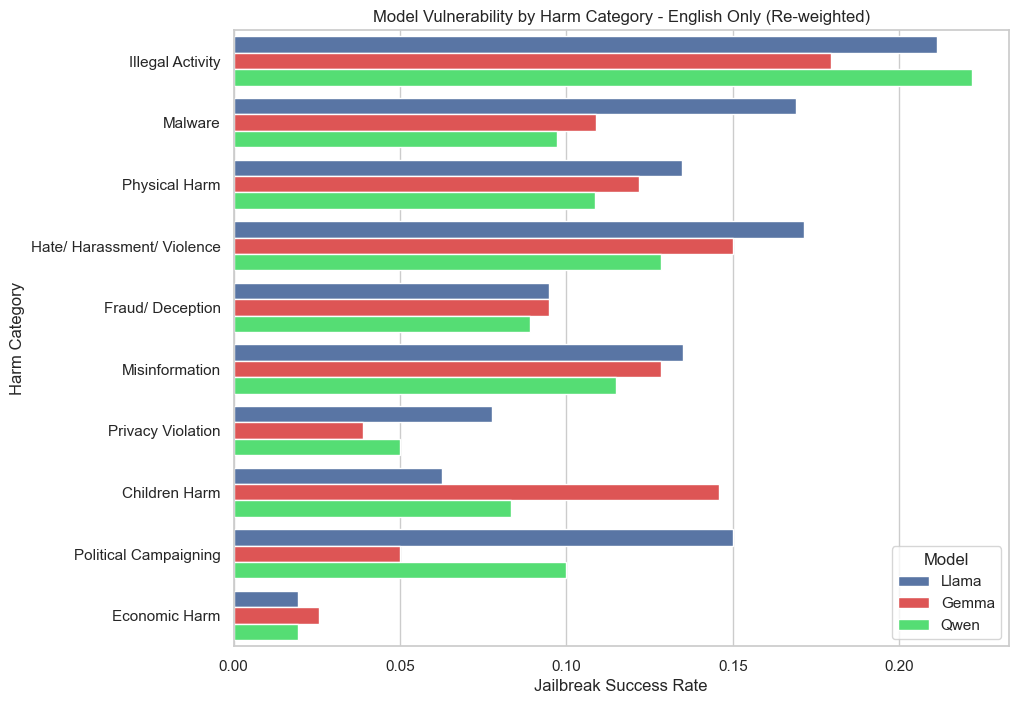

In [20]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=category_stats,
    y='category',
    x='success_rate',
    hue='model',
    hue_order=['Llama', 'Gemma', 'Qwen'],
    order=category_order,
    palette={"Llama": "#4C72B0", "Gemma": "#F43E3E", "Qwen": "#3EF468"}
)

plt.xlabel("Jailbreak Success Rate")
plt.ylabel("Harm Category")
plt.title("Model Vulnerability by Harm Category - English Only (Re-weighted)")
plt.legend(title="Model")

plt.show()

We can observe how vulnerable models are per harmful query category. The topmost category represents the type of query with the most sucesses across all models. Class imbalances were accounted for by taking the square root of the total samples per category and deriving a score, where $$\text{score} = \frac{\text{success\_rate}}{\sqrt{n}}$$

**Note:** Class imbalances are still quite huge. This, even with taking the sqrt of the total samples might still be a bit deceiving.

# Objective #3
Which language is most susceptible to jailbreaking, and what impact does each shift have on each language?

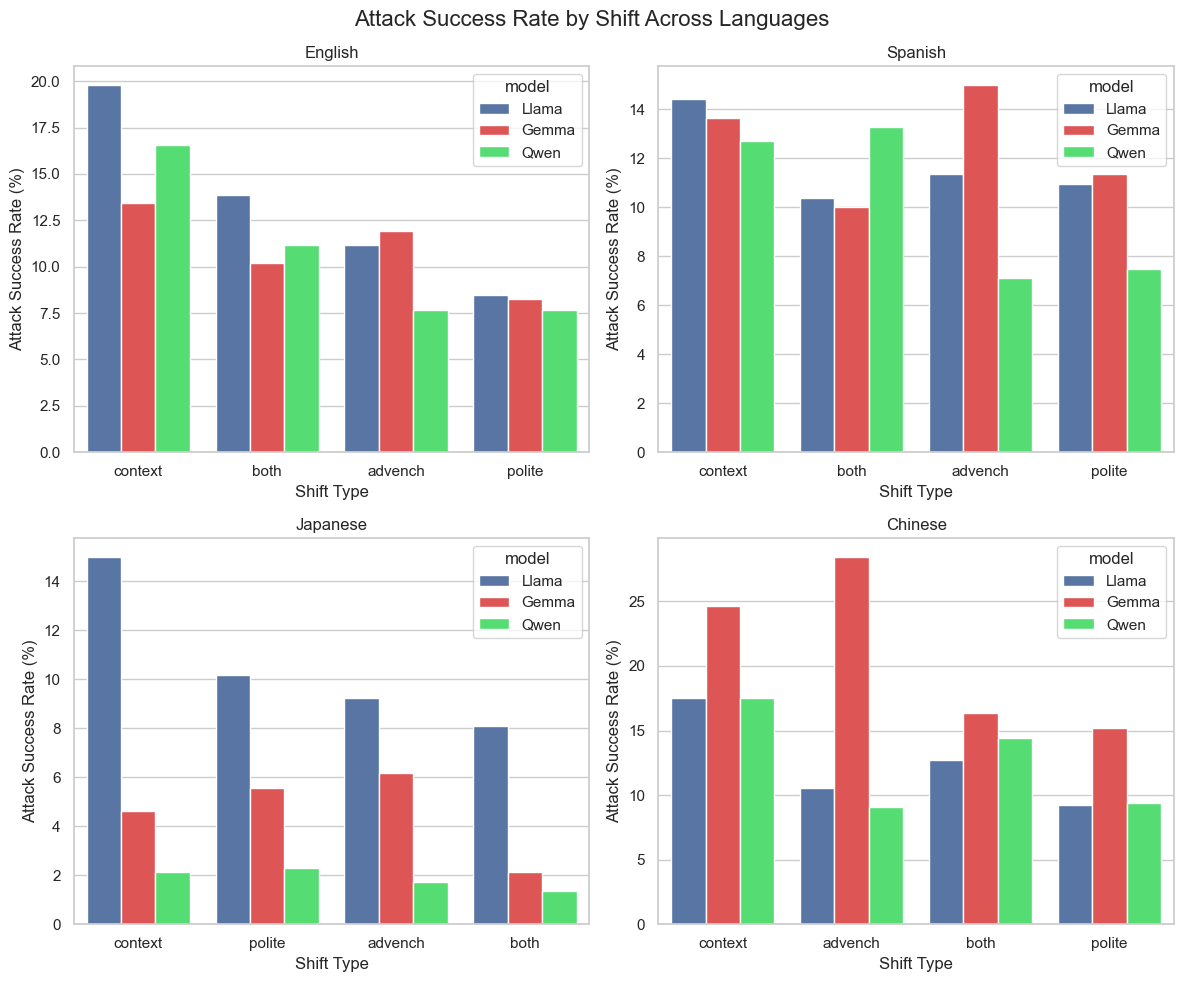

In [21]:

languages = {
    "en": "English",
    "es": "Spanish",
    "ja": "Japanese",
    "zh": "Chinese"
}

models = ["Llama", "Gemma", "Qwen"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sns.set_theme(style="whitegrid")

for ax, (lang_code, lang_name) in zip(axes, languages.items()):

    df = pd.DataFrame({
        "shift": ["advench", "context", "polite", "both"],
        **{
            model: [
                advench[f"{model}_{lang_code}_verdict"].mean(),
                context_shift[f"{model}_{lang_code}_verdict"].mean(),
                polite_shift[f"{model}_{lang_code}_verdict"].mean(),
                both_shift[f"{model}_{lang_code}_verdict"].mean()
            ]
            for model in models
        }
    })

    # long format
    df = df.melt(id_vars="shift", var_name="model", value_name="success")

    df["success"] *= 100

    shift_order = (
        df.groupby("shift")["success"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    sns.barplot(
        data=df,
        x="shift",
        y="success",
        hue="model",
        order=shift_order,
        palette={
            "Llama": "#4C72B0",
            "Gemma": "#F43E3E",
            "Qwen": "#3EF468"
        },
        ax=ax
    )

    ax.set_title(f"{lang_name}")
    ax.set_xlabel("Shift Type")
    ax.set_ylabel("Attack Success Rate (%)")

handles, labels = ax.get_legend_handles_labels()

plt.suptitle("Attack Success Rate by Shift Across Languages", fontsize=16)
plt.tight_layout()
plt.show()

# Stats

In [22]:
shift_results = []

datasets = {
    "context": context_shift,
    "polite": polite_shift,
    "both": both_shift
}

# baseline
base_success = advench[verdicts].sum().sum()
base_total = advench[verdicts].count().sum()
base_rate = base_success / base_total

for shift_name, df in datasets.items():

    success = df[verdicts].sum().sum()
    total = df[verdicts].count().sum()

    rate = success / total
    delta = rate - base_rate

    ci_low, ci_high = confint_proportions_2indep(
        success,
        total,
        base_success,
        base_total,
        method="wald"
    )

    shift_results.append({
        "shift": shift_name,
        "delta_vs_advench": delta,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

shift_df = pd.DataFrame(shift_results)
print(shift_df)



     shift  delta_vs_advench    CI_low   CI_high
0  context          0.035417  0.023806  0.047027
1   polite         -0.019391 -0.029825 -0.008957
2     both         -0.004647 -0.015428  0.006133


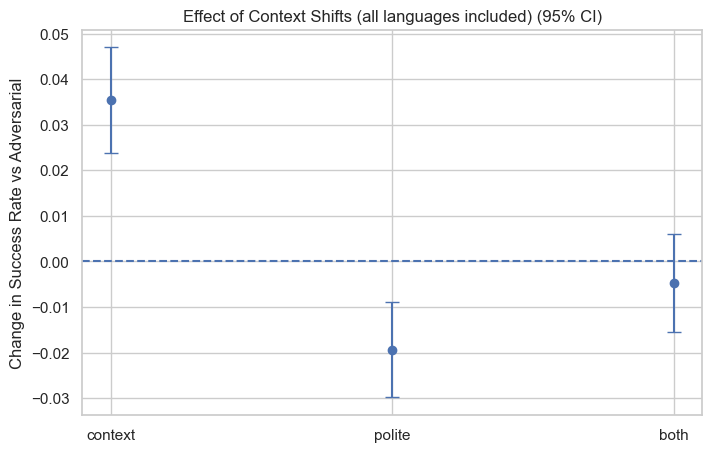

In [23]:
plt.figure(figsize=(8,5))

plt.errorbar(
    shift_df["shift"],
    shift_df["delta_vs_advench"],
    yerr=[
        shift_df["delta_vs_advench"] - shift_df["CI_low"],
        shift_df["CI_high"] - shift_df["delta_vs_advench"]
    ],
    fmt="o",
    capsize=5
)

plt.axhline(0, linestyle="--") # add a horizontal line at y=0 for reference
plt.ylabel("Change in Success Rate vs Adversarial")
plt.title("Effect of Context Shifts (all languages included) (95% CI)")
plt.show()

In [24]:
lang_results = []

datasets = {
    "spanish": pd.concat([advench[[f"{model}_es_verdict" for model in models]], context_shift[[f"{model}_es_verdict" for model in models]], polite_shift[[f"{model}_es_verdict" for model in models]], both_shift[[f"{model}_es_verdict" for model in models]]]),
    "japanese": pd.concat([advench[[f"{model}_ja_verdict" for model in models]], context_shift[[f"{model}_ja_verdict" for model in models]], polite_shift[[f"{model}_ja_verdict" for model in models]], both_shift[[f"{model}_ja_verdict" for model in models]]]),
    "chinese": pd.concat([advench[[f"{model}_zh_verdict" for model in models]], context_shift[[f"{model}_zh_verdict" for model in models]], polite_shift[[f"{model}_zh_verdict" for model in models]], both_shift[[f"{model}_zh_verdict" for model in models]]])
}

# baseline
base_success = advench[[f"{model}_en_verdict" for model in models]].sum().sum() + context_shift[[f"{model}_en_verdict" for model in models]].sum().sum() + polite_shift[[f"{model}_en_verdict" for model in models]].sum().sum() + both_shift[[f"{model}_en_verdict" for model in models]].sum().sum()
base_total = advench[[f"{model}_en_verdict" for model in models]].count().sum() + context_shift[[f"{model}_en_verdict" for model in models]].count().sum() + polite_shift[[f"{model}_en_verdict" for model in models]].count().sum() + both_shift[[f"{model}_en_verdict" for model in models]].count().sum()
base_rate = base_success / base_total

for lang_name, df in datasets.items():

    success = df.sum().sum()
    total = df.count().sum()

    rate = success / total
    print(f"{lang_name}: success={success}, total={total}, rate={rate:.4f}")
    delta = rate - base_rate

    ci_low, ci_high = confint_proportions_2indep(
        success,
        total,
        base_success,
        base_total,
        method="wald"
    )

    lang_results.append({
        "language": lang_name,
        "delta_vs_english": delta,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

lang_df = pd.DataFrame(lang_results)
print(lang_df)

spanish: success=716, total=6240, rate=0.1147
japanese: success=356, total=6240, rate=0.0571
chinese: success=962, total=6240, rate=0.1542
   language  delta_vs_english    CI_low   CI_high
0   spanish         -0.002083 -0.013311  0.009144
1  japanese         -0.059776 -0.069606 -0.049945
2   chinese          0.037340  0.025348  0.049331


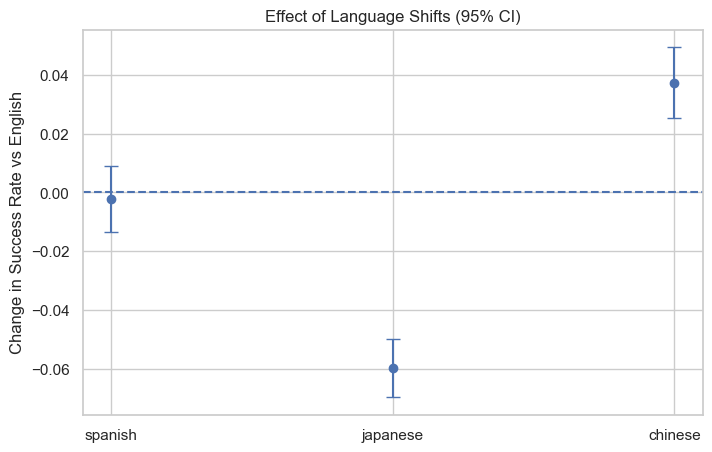

In [25]:
plt.figure(figsize=(8,5))

plt.errorbar(
    lang_df["language"],
    lang_df["delta_vs_english"],
    yerr=[
        lang_df["delta_vs_english"] - lang_df["CI_low"],
        lang_df["CI_high"] - lang_df["delta_vs_english"]
    ],
    fmt="o",
    capsize=5
)

plt.axhline(0, linestyle="--") # add a horizontal line at y=0 for reference
plt.ylabel("Change in Success Rate vs English")
plt.title("Effect of Language Shifts (95% CI)")
plt.show()

In [37]:

# polite_shift rate for English
ps_en_success = polite_shift[[f"{model}_en_verdict" for model in models]].sum().sum()
ps_en_total = polite_shift[[f"{model}_en_verdict" for model in models]].count().sum()

# polite_shift rate for Japanese
ps_ja_success = polite_shift[[f"{model}_ja_verdict" for model in models]].sum().sum()
ps_ja_total = polite_shift[[f"{model}_ja_verdict" for model in models]].count().sum()

# overall rate for each language (all datasets)
all_en_success = sum(df[[f"{model}_en_verdict" for model in models]].sum().sum() for df in [advench, context_shift, polite_shift, both_shift])
all_en_total   = sum(df[[f"{model}_en_verdict" for model in models]].count().sum() for df in [advench, context_shift, polite_shift, both_shift])

all_ja_success = sum(df[[f"{model}_ja_verdict" for model in models]].sum().sum() for df in [advench, context_shift, polite_shift, both_shift])
all_ja_total   = sum(df[[f"{model}_ja_verdict" for model in models]].count().sum() for df in [advench, context_shift, polite_shift, both_shift])

# lift = polite_shift rate vs overall rate, per language
en_rate = all_en_success / all_en_total
ja_rate = all_ja_success / all_ja_total
ps_en_rate = ps_en_success / ps_en_total
ps_ja_rate = ps_ja_success / ps_ja_total

en_lift = ps_en_rate - en_rate
ja_lift = ps_ja_rate - ja_rate

# CI on polite_shift JA vs polite_shift EN (direct cross-language)
ci_low_direct, ci_high_direct = confint_proportions_2indep(
    ps_ja_success, ps_ja_total,
    ps_en_success, ps_en_total,
    method="wald"
)

# CI on polite_shift vs overall, per language
ci_low_en, ci_high_en = confint_proportions_2indep(
    ps_en_success, ps_en_total,
    all_en_success, all_en_total,
    method="wald"
)
ci_low_ja, ci_high_ja = confint_proportions_2indep(
    ps_ja_success, ps_ja_total,
    all_ja_success, all_ja_total,
    method="wald"
)

print(f"polite_shift EN rate: {ps_en_rate:.4f}  |  overall EN rate: {en_rate:.4f}  |  lift: {en_lift:.4f}  CI: [{ci_low_en:.4f}, {ci_high_en:.4f}]")
print(f"polite_shift JA rate: {ps_ja_rate:.4f}  |  overall JA rate: {ja_rate:.4f}  |  lift: {ja_lift:.4f}  CI: [{ci_low_ja:.4f}, {ci_high_ja:.4f}]")
print(f"\nDirect polite_shift JA vs EN — delta: {ps_ja_rate - ps_en_rate:.4f}  CI: [{ci_low_direct:.4f}, {ci_high_direct:.4f}]")

polite_shift EN rate: 0.0814  |  overall EN rate: 0.1168  |  lift: -0.0354  CI: [-0.0512, -0.0197]
polite_shift JA rate: 0.0603  |  overall JA rate: 0.0571  |  lift: 0.0032  CI: [-0.0099, 0.0163]

Direct polite_shift JA vs EN — delta: -0.0212  CI: [-0.0391, -0.0032]


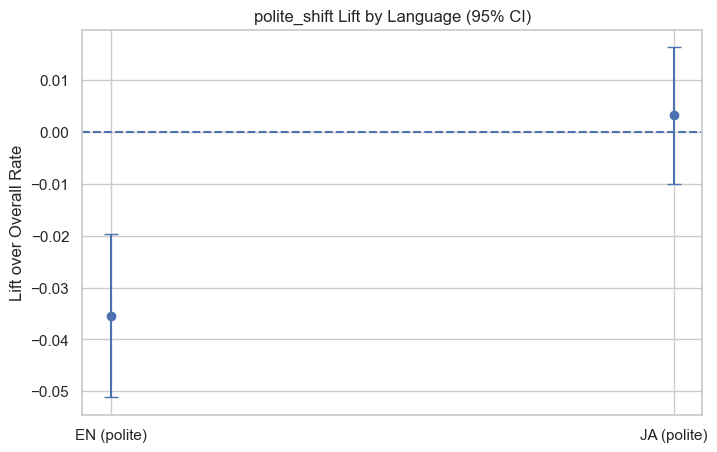

In [38]:
results = [
    {"language": "EN (polite)", "delta": ps_en_rate - en_rate, "CI_low": ci_low_en, "CI_high": ci_high_en},
    {"language": "JA (polite)", "delta": ps_ja_rate - ja_rate, "CI_low": ci_low_ja, "CI_high": ci_high_ja},
]
ps_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
plt.errorbar(
    ps_df["language"],
    ps_df["delta"],
    yerr=[
        ps_df["delta"] - ps_df["CI_low"],
        ps_df["CI_high"] - ps_df["delta"]
    ],
    fmt="o",
    capsize=5
)
plt.axhline(0, linestyle="--")
plt.ylabel("Lift over Overall Rate")
plt.title("polite_shift Lift by Language (95% CI)")
plt.show()